In [4]:
#7-1 CIFAR-10으로 컨볼루션 신경망을 학습하고 모델을 파일에 저장하기.

import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train = x_train.astype(np.float32)/255.0 # ndarray로 변환
x_test = x_test.astype(np.float32)/255.0
y_train = tf.keras.utils.to_categorical(y_train, 10) # 원핫 코드로 변환
y_test = tf.keras.utils.to_categorical(y_test, 10)

#신경망 모델 설계
cnn=Sequential()
cnn.add(Conv2D(32,(3,3), activation='relu', input_shape=(32,32,3)))
cnn.add(Conv2D(32,(3,3), activation='relu'))
cnn.add(MaxPooling2D(pool_size=(2,2)))
cnn.add(Dropout(0.25))
cnn.add(Conv2D(64,(3,3), activation='relu'))
cnn.add(Conv2D(64,(3,3), activation='relu'))
cnn.add(MaxPooling2D(pool_size=(2,2)))
cnn.add(Dropout(0.25))
cnn.add(Flatten())
cnn.add(Dense(512, activation='relu'))
cnn.add(Dropout(0.5))
cnn.add(Dense(10, activation='softmax'))

cnn.compile(loss='categorical_crossentropy', optimizer=Adam(), metrics=['accuracy'])
hist=cnn.fit(x_train,y_train,batch_size=128, epochs=100, validation_data=(x_test,y_test),verbose=2)

res = cnn.evaluate(x_test, y_test, verbose=0)
print("정확률은", res[1]*100)

import matplotlib.pyplot as plt
plt.plot(hist.history['accuracy'], 'r')
plt.plot(hist.history['val_accuracy'], 'r--')
plt.title('Model accuracy')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='best')
plt.grid()
plt.show()
cnn.save("my_cnn_for_deploy.h5")

Epoch 1/100


KeyboardInterrupt: 

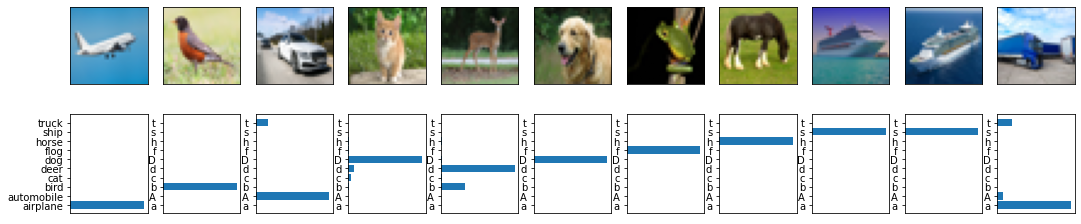

In [22]:
#7-2 폴더에 담겨 있는 영상을 인식
import numpy as np
import tensorflow as tf
from PIL import Image
import os

cnn = tf.keras.models.load_model("C:/Users/82107/Desktop/MasterCourse/실습/cnn_deploy.h5") #학습된 모델 불러오기
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'flog', 'horse', 'ship', 'truck']

x_test = []
for filename in os.listdir("C:/Users/82107/Desktop/MasterCourse/실습/test_images"):
    if 'jpg' not in filename:
        continue;
    img = Image.open("C:/Users/82107/Desktop/MasterCourse/실습/test_images/" + filename)
    x = np.asarray(img.resize([32,32]))/255.0
    x_test.append(x)

x_test = np.asarray(x_test)

pred = cnn.predict(x_test)

import matplotlib.pyplot as plt

n=len(x_test)
plt.figure(figsize=(18,4))

for i in range(n):
    plt.subplot(2,n,i+1)
    plt.imshow(x_test[i])
    plt.xticks([]);
    plt.yticks([]);
    plt.subplot(2,n,n+i+1)
    
    if i==0:
        plt.barh(class_names, pred[i])
    else:
        plt.barh(['a','A','b','c','d','D','f','h','s','t'], pred[i])
    plt.xticks([])
    

In [24]:
#7-3 영상 바구니 담기 - 부류에 따라 영상을 폴더에 담기
import numpy as np
import tensorflow as tf
from PIL import Image
import os

cnn = tf.keras.models.load_model("C:/Users/82107/Desktop/MasterCourse/실습/cnn_deploy.h5") #학습된 모델 불러오기
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'flog', 'horse', 'ship', 'truck'] #CIFAR-10의 분류 이름

x_test=[]
img_orig=[]
fname=[]

for filename in os.listdir("C:/Users/82107/Desktop/MasterCourse/실습/test_images"):
    if 'jpg' not in filename:
        continue;
    img = Image.open("C:/Users/82107/Desktop/MasterCourse/실습/test_images/" + filename)
    img_orig.append(img)
    fname.append(filename)
    x = np.asarray(img.resize([32,32]))/255.0
    x_test.append(x)
    
x_test=np.asarray(x_test)

pred = cnn.predict(x_test) #예측

os.chdir('C:/Users/82107/Desktop/MasterCourse/실습/test_images/')
if not os.path.isdir('class_buckets'):
    os.mkdir('class_buckets')
os.chdir('class_buckets')
for i in range(len(class_names)):
    if not os.path.isdir(class_names[i]):
        os.mkdir(class_names[i]) #부류별로 폴더만들기
        
        
for i in range(len(x_test)):
    print(i)
    folder_name = class_names[np.argmax(pred[i])] # 인식 결과에 따라 폴더에 저장
    os.chdir(folder_name)
    img_orig[i].save(fname[i])
    os.chdir('..')


0
1
2
3
4
5
6
7
8
9
10


In [1]:
# 7-4 다국어 단어 공부: tkinter를 이용한 대화형 인터페이스
import numpy as np
import tensorflow as tf
import tkinter as tk
from tkinter import filedialog
from PIL import Image, ImageTk
import winsound
from gtts import gTTS
import playsound
import os

cnn = tf.keras.models.load_model("C:/Users/82107/Desktop/MasterCourse/실습/cnn_deploy.h5") #학습된 모델 불러오기

class_names_en = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'flog', 'horse', 'ship', 'truck']
class_names_fr = ['avion', 'voiture', 'oiseau', 'chatte', 'biche', 'chienne', 'grenouille', 'jument', 'navire', 'un camion']
class_names_de = ['Flugzeug', 'Automobil', 'Vogel', 'Katze', 'Hirsch', 'Hund', 'Frosch', 'Pferd', 'Schiff', 'LKW']

class_id = 0
tk_img=''


def process_image(): # 사용자가 선택한 영상을 인식하고 결과를 저장
    global class_id, tk_img
    
    fname = filedialog.askopenfilename() #영상 선택
    img = Image.open(fname)
    tk_img=img.resize([128,128])
    tk_img=ImageTk.PhotoImage(tk_img)
    
    canvas.create_image((canvas.winfo_width()/2, canvas.winfo_height()/2), image=tk_img, anchor='center')
    
    x_test = []
    x=np.asarray(img.resize([32,32]))/255.0
    x_test.append(x)
    x_test = np.asarray(x_test)
    res = cnn.predict(x_test)
    class_id = np.argmax(res)
    
    label_en['text'] = '영어: ' + class_names_en[class_id] # 레이블 위젯용 텍스트 만들기
    label_fr['text'] = '프랑스어: ' + class_names_fr[class_id] # 레이블 위젯용 텍스트 만들기
    label_de['text'] = '독일어: ' + class_names_de[class_id] # 레이블 위젯용 텍스트 만들기
    winsound.Beep(frequency=500, duration=250)
    
def tts_english():
    tts = gTTS(text=class_names_en[class_id], lang='en')
    os.remove('word.mp3')
    tts.save('word.mp3')
    playsound.playsound('word.mp3', True)
    
def tts_french():
    tts = gTTS(text=class_names_fr[class_id], lang='fr')
    os.remove('word.mp3')
    tts.save('word.mp3')
    playsound.playsound('word.mp3', True)
    
def tts_deutsch():
    tts = gTTS(text=class_names_de[class_id], lang='de')
    os.remove('word.mp3')
    tts.save('word.mp3')
    playsound.playsound('word.mp3', True)
    
def quit_program():
    win.destroy()
    
win = tk.Tk()
win.title('다국어 단어 공부')
win.geometry('512x500')

process_button = tk.Button(win, text='영상 선택', command=process_image) #위젯 생성
quit_button = tk.Button(win, text='끝내기', command=quit_program)
canvas = tk.Canvas(win, width = 256, height=256, bg='cyan', bd=4)

label_en = tk.Label(win, width=16, height=1, bg="yellow", bd=4, text='영어', anchor='w')
label_fr = tk.Label(win, width=16, height=1, bg="yellow", bd=4, text='프랑스어', anchor='w')
label_de = tk.Label(win, width=16, height=1, bg="yellow", bd=4, text='독일어', anchor='w')

tts_en = tk.Button(win, text='듣기', command=tts_english)
tts_fr = tk.Button(win, text='듣기', command=tts_french)
tts_de = tk.Button(win, text='듣기', command=tts_deutsch)

process_button.grid(row=0, column=0)
quit_button.grid(row=1, column=0)
canvas.grid(row=0, column=1)
label_en.grid(row=1, column=1, sticky='e')
label_fr.grid(row=2, column=1, sticky='e')
label_de.grid(row=3, column=1, sticky='e')
tts_en.grid(row=1, column=2, sticky='w')
tts_fr.grid(row=2, column=2, sticky='w')
tts_de.grid(row=3, column=2, sticky='w')

win.mainloop()
    

Exception in Tkinter callback
Traceback (most recent call last):
  File "C:\Users\82107\anaconda3\lib\site-packages\PIL\Image.py", line 2916, in open
    fp.seek(0)
AttributeError: 'str' object has no attribute 'seek'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "C:\Users\82107\anaconda3\lib\tkinter\__init__.py", line 1892, in __call__
    return self.func(*args)
  File "<ipython-input-1-2f43f9bf7540>", line 26, in process_image
    img = Image.open(fname)
  File "C:\Users\82107\anaconda3\lib\site-packages\PIL\Image.py", line 2918, in open
    fp = io.BytesIO(fp.read())
AttributeError: 'str' object has no attribute 'read'


KeyboardInterrupt: 

In [32]:
# 7-5 opencv와 웹캠을 이용한 영상 인식
import numpy as np
import tensorflow as tf
import tkinter as tk
from tkinter import filedialog
from PIL import Image, ImageTk
import winsound
from gtts import gTTS
import playsound
import os
import cv2

cnn = tf.keras.models.load_model("C:/Users/82107/Desktop/MasterCourse/실습/cnn_deploy.h5") #학습된 모델 불러오기

class_names_en = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'flog', 'horse', 'ship', 'truck']
class_names_fr = ['avion', 'voiture', 'oiseau', 'chatte', 'biche', 'chienne', 'grenouille', 'jument', 'navire', 'un camion']
class_names_de = ['Flugzeug', 'Automobil', 'Vogel', 'Katze', 'Hirsch', 'Hund', 'Frosch', 'Pferd', 'Schiff', 'LKW']

class_id = 0
tk_img=''

def process_video():
    print("111");
    global class_id, tk_img
    print("222");
    video=cv2.VideoCapture(0)
    print("333");
    while video.isOpened():
        print("1");
        success, frame=video.read()
        print("2")
        if success:
            cv2.imshow('Camera', frame)
            key = cv2.waitKey(1) & 0xFF
            if key==27:
                break
    
    video.release()
    cv2.destroyAllWindows()
    
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    img = Image.fromarray(frame)
    
    tk_img = img.resize([128,128])
    tk_img=ImageTk.PhotoImage(tk_img)
    canvas.create_image((canvas.winfo_width()/2, canvas.winfo_height()/2),
                        image = tk_img, anchor='center')
    
    x_test = []
    x=np.asarray(img.resize([32,32])) / 255.0
    x_test.append(x)
    x_test = np.asarray(x_test)
    res = cnn.predict(x_test)
    res = cnn.predict(x_test)
    class_id = np.argmax(res)
    
    label_en['text'] = '영어: ' + class_names_en[class_id] # 레이블 위젯용 텍스트 만들기
    label_fr['text'] = '프랑스어: ' + class_names_fr[class_id] # 레이블 위젯용 텍스트 만들기
    label_de['text'] = '독일어: ' + class_names_de[class_id] # 레이블 위젯용 텍스트 만들기
    winsound.Beep(frequency=500, duration=250)
    
def tts_english():
    tts = gTTS(text=class_names_en[class_id], lang='en')
    os.remove('word.mp3')
    tts.save('word.mp3')
    playsound.playsound('word.mp3', True)
    
def tts_french():
    tts = gTTS(text=class_names_fr[class_id], lang='fr')
    os.remove('word.mp3')
    tts.save('word.mp3')
    playsound.playsound('word.mp3', True)
    
def tts_deutsch():
    tts = gTTS(text=class_names_de[class_id], lang='de')
    os.remove('word.mp3')
    tts.save('word.mp3')
    playsound.playsound('word.mp3', True)
    
def quit_program():
    win.destroy()
    
win = tk.Tk()
win.title('다국어 단어 공부')
win.geometry('512x500')

process_button = tk.Button(win, text='비디오 선택', command=process_video) #위젯 생성
quit_button = tk.Button(win, text='끝내기', command=quit_program)
canvas = tk.Canvas(win, width = 256, height=256, bg='cyan', bd=4)

label_en = tk.Label(win, width=16, height=1, bg="yellow", bd=4, text='영어', anchor='w')
label_fr = tk.Label(win, width=16, height=1, bg="yellow", bd=4, text='프랑스어', anchor='w')
label_de = tk.Label(win, width=16, height=1, bg="yellow", bd=4, text='독일어', anchor='w')

tts_en = tk.Button(win, text='듣기', command=tts_english)
tts_fr = tk.Button(win, text='듣기', command=tts_french)
tts_de = tk.Button(win, text='듣기', command=tts_deutsch)

process_button.grid(row=0, column=0)
quit_button.grid(row=1, column=0)
canvas.grid(row=0, column=1)
label_en.grid(row=1, column=1, sticky='e')
label_fr.grid(row=2, column=1, sticky='e')
label_de.grid(row=3, column=1, sticky='e')
tts_en.grid(row=1, column=2, sticky='w')
tts_fr.grid(row=2, column=2, sticky='w')
tts_de.grid(row=3, column=2, sticky='w')

win.mainloop()

111
222
333


Exception in Tkinter callback
Traceback (most recent call last):
  File "C:\Users\82107\anaconda3\lib\tkinter\__init__.py", line 1892, in __call__
    return self.func(*args)
  File "<ipython-input-32-cb9593ecba2d>", line 41, in process_video
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
UnboundLocalError: local variable 'frame' referenced before assignment


In [44]:
# 7-6 웹캠을 이용해 침입자 검출하기
import numpy as np
import cv2
import winsound

classes = []
f = open('C:/Users/82107/Desktop/MasterCourse/실습/coco_names.txt', 'r')
classes = [line.strip() for line in f.readlines()]
colors = np.random.uniform(0, 255, size=(len(classes),3))

yolo_model = cv2.dnn.readNet('yolov3.weights', 'yolov3.cfg') #욜로 읽어오기
layer_names = yolo_model.getLayerNames()

out_layers = [layer_names[i[0]-1] for i in yolo_model.getUnconnectedOutLayers()]

def process_video():
    video = cv2.VideoCapture(0)
    while video.isOpened():
        success, img = video.read()
        if success:
            height, width, channels = img.shape
            blob = cv2.dnn.blobFromImage(img, 1.0/256, (448,448), (0,0,0), swapRB = True, crop=False)
            yolo_model.setInput(blob)
            output3 = yolo_model.forward(out_layers)
            
            class_ids, confidences, boxes = [],[],[]
            for output in output3:
                for vec85 in output:
                    scores = vec85[5:]
                    class_id = np.argmax(scores)
                    confidences = scores[class_id]
                    if onfidence > 0.5:
                        centerx, centery = int(vec85[0]*width),int(vec85[1]*height)
                    w,h = int(vec85[2]*width),int(vec85[3]*height)
                    x,y = int(centerx-w/2), int(centery-h/2)
                    boxes.append([x,y,w,h])
                    confidences.append(float(confidence))
                    class_ids.append(class_id)
                    indexes = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)
                        
                    for i in range(len(boxes)):
                        if i in indexes:
                            x,y,w,h = boxes[i]
                            test = str(classes[class_ids[i]]) + '%.3f'%confidences[i]
                            cv2.rectangle(img, (x,y),(x+w, y+h), colors[class_ids[i]], 2)
                            cv2.putText(img,text,(x,y+30), cv2.FONT_HERSHEY_PLAIN, 2, colors[class_ids[i]],2)
                            
            cv2.imshow('Object detection', img)
            if 0 in class_ids:
               print('사람이 나타났다!')
               winsound.Beep(frquency = 2000, duration=500)
                    
        key = cv2.waitKey(1) & 0xFF
        if key==27: break
            
                    
    video.release()
    cv2.destroyAllWindows()

process_video()